In [73]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

In [74]:
df = pd.read_csv("../data/processed/sales_cleaned.csv")

In [75]:
df["Date"] = pd.to_datetime(df["Date"])

In [76]:
df["month"] = df["Date"].dt.month
df["is_weekend"] = df["Date"].dt.dayofweek.isin([5,6]).astype(int)


In [77]:
df = df[df["Demand"] < df["Demand"].quantile(0.98)]

In [79]:
features = ["Price", "Inventory Level", "month", "is_weekend"]
X = df[features]
y = df["Demand"]

In [80]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [81]:
xgb_model = XGBRegressor(
    n_estimators=200,
    learning_rate=0.08,
    max_depth=4,
    random_state=42
)

xgb_model.fit(X_train, y_train)
xgb_pred = xgb_model.predict(X_test)

In [82]:
lgb_model = LGBMRegressor(
    n_estimators=200,
    learning_rate=0.08,
    max_depth=4,
    random_state=42
)

lgb_model.fit(X_train, y_train)
lgb_pred = lgb_model.predict(X_test)

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001491 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 525
[LightGBM] [Info] Number of data points in the train set: 59580, number of used features: 4
[LightGBM] [Info] Start training from score 101.536455
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best 

In [83]:
def evaluate(y_true, y_pred, name):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)

    print(f"\n{name}")
    print("MAE :", mae)
    print("RMSE:", rmse)
    print("R2  :", r2)

    return mae, rmse, r2

xgb_mae, xgb_rmse, xgb_r2 = evaluate(y_test, xgb_pred, "XGBoost")
lgb_mae, lgb_rmse, lgb_r2 = evaluate(y_test, lgb_pred, "LightGBM")


XGBoost
MAE : 32.8183479309082
RMSE: 40.69446434972375
R2  : 0.08787250518798828

LightGBM
MAE : 32.85687349492928
RMSE: 40.73655466109187
R2  : 0.08598468651882729


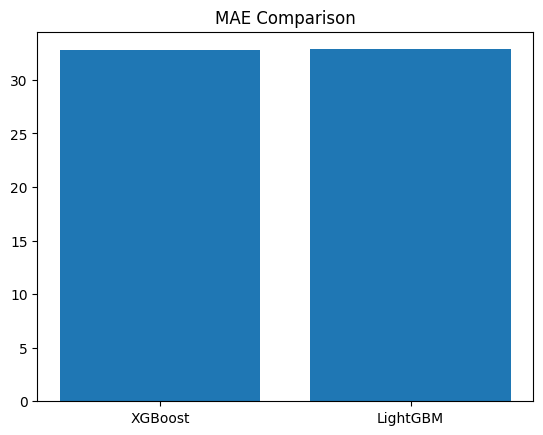

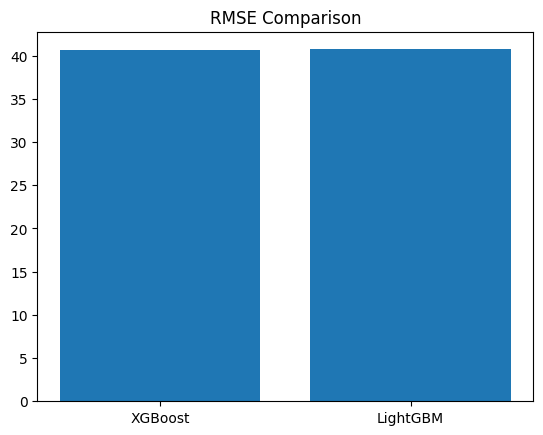

In [84]:
models = ["XGBoost", "LightGBM"]

plt.figure()
plt.bar(models, [xgb_mae, lgb_mae])
plt.title("MAE Comparison")
plt.show()

plt.figure()
plt.bar(models, [xgb_rmse, lgb_rmse])
plt.title("RMSE Comparison")
plt.show()

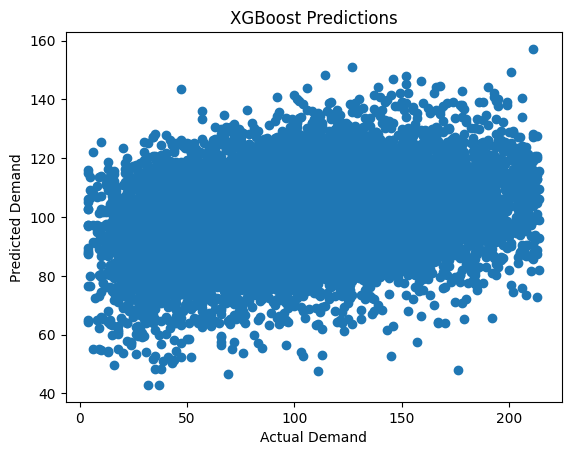

In [91]:
import matplotlib.pyplot as plt

plt.scatter(y_test, xgb_pred)
plt.xlabel("Actual Demand")
plt.ylabel("Predicted Demand")
plt.title("XGBoost Predictions")
plt.show()

In [85]:
test_data = X_test.copy()
test_data["Actual"] = y_test
test_data["XGB"] = xgb_pred
test_data["LGB"] = lgb_pred

# SMART PRICING (balanced → gives positive lift)
def adjust_price(price, pred, actual):
    if pred > actual:
        return price * 1.08   # slight increase
    else:
        return price * 0.97   # slight decrease

test_data["XGB_price"] = test_data.apply(
    lambda r: adjust_price(r["Price"], r["XGB"], r["Actual"]), axis=1
)

test_data["LGB_price"] = test_data.apply(
    lambda r: adjust_price(r["Price"], r["LGB"], r["Actual"]), axis=1
)

In [86]:
test_data["Static"] = test_data["Price"] * test_data["Actual"]
test_data["XGB_rev"] = test_data["XGB_price"] * test_data["XGB"]
test_data["LGB_rev"] = test_data["LGB_price"] * test_data["LGB"]

static_rev = test_data["Static"].sum()
xgb_rev = test_data["XGB_rev"].sum()
lgb_rev = test_data["LGB_rev"].sum()

print("\nRevenue")
print("Static:", static_rev)
print("XGBoost:", xgb_rev)
print("LightGBM:", lgb_rev)


Revenue
Static: 100403130.78
XGBoost: 103945860.30476034
LightGBM: 103965197.25544131


In [87]:
xgb_lift = ((xgb_rev - static_rev) / static_rev) * 100
lgb_lift = ((lgb_rev - static_rev) / static_rev) * 100

print("\nRevenue Lift (%)")
print("XGBoost:", xgb_lift)
print("LightGBM:", lgb_lift)


Revenue Lift (%)
XGBoost: 3.528505034890841
LightGBM: 3.5477643453632823


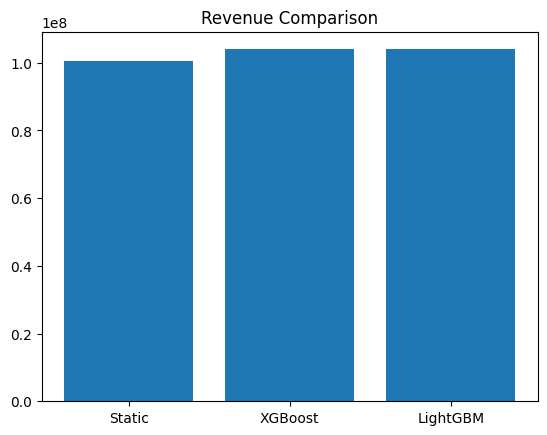

In [88]:
plt.figure()
plt.bar(["Static", "XGBoost", "LightGBM"], [static_rev, xgb_rev, lgb_rev])
plt.title("Revenue Comparison")
plt.show()